In [ ]:
!pip install thop

In [ ]:
!pip install torchinfo

In [ ]:
!pip install icecream

In [ ]:
!git clone https://github.com/Mdraqibkhan/Spectroformer.git

Cloning into 'Spectroformer'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 230 (delta 9), reused 0 (delta 0), pack-reused 212 (from 2)
Receiving objects: 100% (230/230), 12.18 MiB | 14.52 MiB/s, done.
Resolving deltas: 100% (117/117), done.


In [ ]:
%cd Spectroformer

/content/Spectroformer


In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os

# ====== CONFIG ======
image_path = "/content/d_r_47_.jpg"
output_path = "/content/output.png"
model_path = "/content/Spectroformer/checkpoints/best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====== LOAD MODEL ======
my_net = torch.load(model_path, weights_only=False).to(device)
my_net.eval()

# ====== TRANSFORM ======
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
# ====== LOAD IMAGE ======
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# ====== INFERENCE ======
with torch.no_grad():
    output = my_net(input_tensor)[0]

# ====== POSTPROCESS ======
output = output.squeeze(0).cpu()
output = (output * 0.5) + 0.5   # denormalize
output = output.clamp(0, 1)

# convert to PIL image
to_pil = transforms.ToPILImage()
output_image = to_pil(output)

# ====== SAVE ======
output_image.save(output_path)

print("✅ Output saved at:", output_path)

✅ Output saved at: /content/output.png


In [ ]:
import torch
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model_name = "jimmy1020/segformer-suim"
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
preprocessor = SegformerImageProcessor.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

(np.float64(-0.5), np.float64(479.5), np.float64(447.5), np.float64(-0.5))

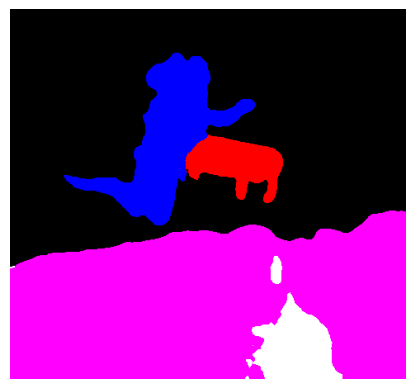

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

image = Image.open("/content/d_r_47_.jpg").convert("RGB")

inputs = preprocessor(images = image, return_tensors = "pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
  outputs = model(**inputs)

logits = outputs.logits

upsampled_logits = F.interpolate(
    logits,
    size = image.size[::-1],
    mode = "bilinear",
    align_corners = False
)

pred_mask = upsampled_logits.argmax(dim = 1)[0]

palette = {
    0: (0,   0,   0),      # BW
    1: (0,   0, 255),      # HD
    2: (0, 255,   0),      # PF
    3: (0, 255, 255),      # WR
    4: (255, 0,   0),      # RO
    5: (255, 0, 255),      # RI
    6: (255, 255, 0),      # FV
    7: (255, 255, 255)     # SR
}

color_mask = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype = np.uint8)

for class_id, color in palette.items():
  color_mask[pred_mask.cpu().numpy() == class_id] = color

plt.imshow(color_mask)
plt.axis('off')

In [ ]:
import torch
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

repo_id = "jimmy1020/mask2former-suim"


processor = AutoImageProcessor.from_pretrained(repo_id)
model = Mask2FormerForUniversalSegmentation.from_pretrained(repo_id)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/275M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=96, out_features=96, bias=True)
                      (key): Linear(in_features=96, out_features=96, bias=True)
                      (value): Lin

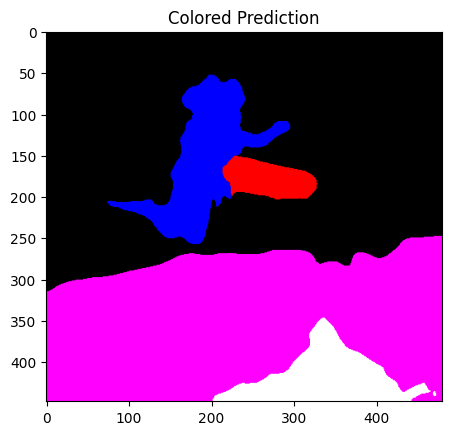

In [ ]:
from PIL import Image

image = Image.open("/content/d_r_47_.jpg").convert("RGB")

inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

result = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]   # (H, W)
)[0]

import numpy as np

palette = {
    0:(0,0,0),
    1:(255,0,0),
    2:(0,255,0),
    3:(0,0,255),
    4:(255,255,0),
    5:(0,255,255),
    6:(255,0,255),
    7:(255,255,255)
}

pred = result.cpu().numpy()
color_mask = np.zeros((pred.shape[0], pred.shape[1], 3), dtype=np.uint8)

for cls, color in palette.items():
    color_mask[pred == cls] = color

plt.imshow(color_mask)
plt.title("Colored Prediction")
plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content

/content


In [1]:
!git clone https://github.com/siriusPRX/ForensicsSAM.git

Cloning into 'ForensicsSAM'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 137 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 3.35 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
%cd /content/ForensicsSAM

/content/ForensicsSAM


In [4]:
!cp /content/drive/MyDrive/weight.zip /content/ForensicsSAM/
!unzip /content/ForensicsSAM/weight.zip

Archive:  /content/ForensicsSAM/weight.zip
   creating: weight/
  inflating: weight/adversary_experts.pth  
  inflating: weight/adversary_detector.pth  
  inflating: weight/sam_vit_h_4b8939.pth  
  inflating: weight/forgery_experts.pth  


In [6]:
!pip install icecream

In [7]:
# ================================
# 🔥 ForensicsSAM Single Image Inference
# ================================

import torch
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import os

# ===== IMPORT YOUR MODULES =====
from segment_anything import sam_model_registry
from forensics_sam import ForensicsSAM
from adversary_detector import AdversaryDetector

# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===== MODEL CONFIG =====
model_type = ['vit_b', 'vit_l', 'vit_h']
checkpoint = {
    'vit_b': './weight/sam_vit_b_01ec64.pth',
    'vit_l': './weight/sam_vit_l_0b3195.pth',
    'vit_h': './weight/sam_vit_h_4b8939.pth'
}

sam_type = model_type[2]   # vit_h (best but heavy)
r = 8
image_size = 1024

# ===== LOAD SAM =====
print("Loading SAM...")
sam, _ = sam_model_registry[sam_type](
    image_size=image_size,
    checkpoint=checkpoint[sam_type]
)
sam = sam.to(device)

# ===== LOAD FORENSICS MODEL =====
print("Loading ForensicsSAM...")
forensics_sam = ForensicsSAM(sam, r).to(device).eval()

# ===== LOAD ADVERSARY DETECTOR =====
print("Loading Adversary Detector...")
adv_detector = AdversaryDetector().to(device).eval()
adv_detector.load_detector("./weight/adversary_detector.pth")


Using device: cuda
Loading SAM...
Loading ForensicsSAM...
./weight/forgery_experts.pth
./weight/adversary_experts.pth
Loading Adversary Detector...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


In [ ]:
# from torchinfo import summary

# summary(
#     forensics_sam,
#     input_data=[torch.randn(1,3,1024,1024).to(device), torch.tensor(0).to(device)]
# )

Layer (type:depth-idx)                                  Output Shape              Param #
ForensicsSAM                                            [1, 1, 256, 256]          --
├─Sam: 1-3                                              --                        (recursive)
│    └─ImageEncoderViT: 2-1                             [1, 256, 64, 64]          5,242,880
│    │    └─PatchEmbed: 3-1                             [1, 64, 64, 1280]         (984,320)
│    │    └─ModuleList: 3-2                             --                        637,089,280
│    │    └─Sequential: 3-3                             [1, 256, 64, 64]          (918,528)
├─ForgeryDetector: 1-2                                  [1, 1]                    --
│    └─AdaptiveAvgPool2d: 2-2                           [1, 256, 1, 1]            --
│    └─Sequential: 2-3                                  [1, 1]                    --
│    │    └─Flatten: 3-4                                [1, 256]                  --
│    │    └─Linear: 3

In [18]:
import cv2
import numpy as np

# Read images
background = cv2.imread("/content/Ian GoodFello.jpg")
obj = cv2.imread("/content/football.png")

# Resize object if needed
obj = cv2.resize(obj, (150, 150))

# Position where object will be pasted
x, y = 200, 100

# Copy object
background[y:y+150, x:x+150] = obj

cv2.imwrite("forged_image.jpg", background)

True

In [21]:
import cv2
import numpy as np

bg = cv2.imread("/content/Ian GoodFello.jpg")
obj = cv2.imread("/content/football.png")

obj = cv2.resize(obj, (200,200))

gray = cv2.cvtColor(obj, cv2.COLOR_BGR2GRAY)

_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

mask_inv = cv2.bitwise_not(mask)

x, y = 150, 120

roi = bg[y:y+200, x:x+200]

bg_part = cv2.bitwise_and(roi, roi, mask=mask_inv)
obj_part = cv2.bitwise_and(obj, obj, mask=mask)

dst = cv2.add(bg_part, obj_part)

bg[y:y+200, x:x+200] = dst

cv2.imwrite("forged_image.jpg", bg)

True

In [22]:
image_path = "/content/ForensicsSAM/forged_image.jpg"   # 👈 CHANGE THIS
print("Reading image:", image_path)

image = Image.open(image_path).convert("RGB")

# ===== TRANSFORM =====
transform = transforms.Compose([
    transforms.Resize((1024, 1024)),   # required for SAM
    transforms.ToTensor(),
])

input_tensor = transform(image).unsqueeze(0).to(device)

# ===== INFERENCE =====
print("Running inference...")

with torch.no_grad():
    logits, _ = adv_detector(input_tensor)
    preds = torch.argmax(logits, dim=1)
    print(preds)
    print(preds.shape)

    mask_prediction, cls_prediction = forensics_sam(input_tensor, preds)

    mask_prediction = torch.sigmoid(mask_prediction)

# ===== POSTPROCESS =====
mask = mask_prediction.squeeze(0).cpu()
mask_binary = (mask > 0.5).float()

# ===== SAVE RESULTS =====
os.makedirs("outputs", exist_ok=True)

to_pil = transforms.ToPILImage()

# Save mask
mask_img = to_pil(mask_binary)
mask_path = "outputs/mask.png"
mask_img.save(mask_path)

Reading image: /content/ForensicsSAM/forged_image.jpg
Running inference...
tensor([0], device='cuda:0')
torch.Size([1])


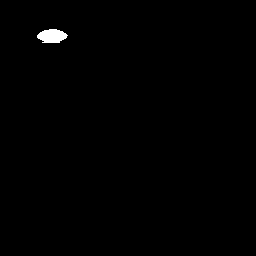

In [23]:
from torchvision.transforms import ToPILImage
from IPython.display import display

mask = mask_binary.squeeze().cpu()  # remove extra dims

mask_img = ToPILImage()(mask)

display(mask_img)